In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import copy
from scipy.stats import ks_2samp, ttest_ind
from sklearn.metrics import roc_auc_score, average_precision_score, auc, precision_recall_curve, roc_curve
from sklearn.model_selection import train_test_split

seed = 0

In [2]:
data = pd.read_csv('user_item_ratings.csv')

## EDA

In [3]:
data.head()

,user,item,x,observed,liked
0,1,1,1.546881,1,1
1,2,1,0.178921,1,0
2,3,1,-0.282547,1,1
3,4,1,-0.767299,0,0
4,5,1,-0.576404,1,0


In [4]:
#check sample split
data.groupby(['observed']).count()

,user,item,x,liked
observed,,,,
0,285,285,285,285
1,2515,2515,2515,2515


In [5]:
#check sample split
data.groupby(['observed', 'liked']).count()

user  item     x
observed liked                  
0        0       165   165   165
         1       120   120   120
1        0      1468  1468  1468
         1      1047  1047  1047

In [6]:
#split into train/test
df_train = data[data['observed'] == 1]
df_test = data[data['observed'] == 0]

In [7]:
#are there any users or items in the test set that aren't in train?
print(np.setdiff1d(df_test['item'].unique(), df_train['item'].unique()))
print(np.setdiff1d(df_test['user'].unique(), df_train['user'].unique()))

[]
[]


test set does not contain any novel items or users not present in train set

total like rate across all users and items:  0.4163021868787276
------------------------------------


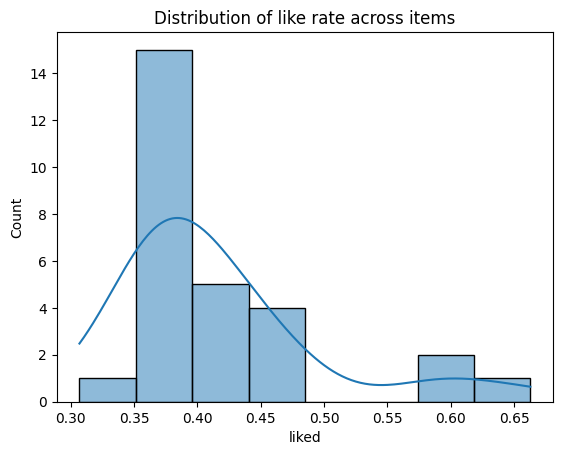

mean like rate across items:  0.4167819401318013
std of like rate across items:  0.08069554186523806


item
4    0.590909
5    0.662791
6    0.595506
Name: liked, dtype: float64

In [8]:
#liked ratios
print('total like rate across all users and items: ', df_train.liked.mean())

#distribution for liked across items
print('------------------------------------')
# print('like rate for each item')
# for item in df_train.item.unique():
#     print('like rate for item', item, ': ', df_train[df_train.item == item].liked.mean())

item_lr = df_train.groupby('item').liked.mean()

sns.histplot(item_lr, kde=True)
plt.title('Distribution of like rate across items')
plt.show()

mu_lr_items = df_train.groupby('item').liked.mean().mean()
sigma_lr_items = df_train.groupby('item').liked.mean().std()

print('mean like rate across items: ', mu_lr_items)
print('std of like rate across items: ', sigma_lr_items)

#any outliers?
lb = mu_lr_items - 2*sigma_lr_items
ub = mu_lr_items + 2*sigma_lr_items

outlier_items = item_lr[(item_lr > ub) | (item_lr < lb)]
outlier_items

Items 4-6 seem to have particularly high like ratios (>2 std from mean)

------------------------------------


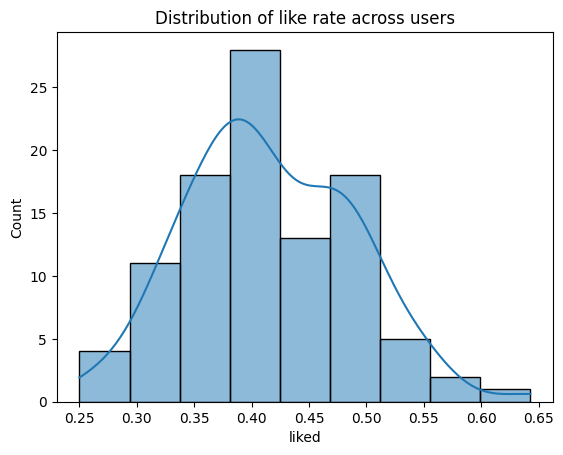

mean like rate across users:  0.4164030623161058
std of like rate across users:  0.0726016493666371


user
19    0.250000
20    0.642857
75    0.269231
Name: liked, dtype: float64

In [9]:
#distribution for liked across users
print('------------------------------------')
# print('like rate for each user')
# for user in df_train.user.unique():
#     print('like rate for user', user, ': ', df_train[df_train.user == user].liked.mean())

user_lr = df_train.groupby('user').liked.mean()

sns.histplot(user_lr, kde=True)
plt.title('Distribution of like rate across users')
plt.show()

mu_lr_users = df_train.groupby('user').liked.mean().mean()
sigma_lr_users = df_train.groupby('user').liked.mean().std()

print('mean like rate across users: ', mu_lr_users)
print('std of like rate across users: ', sigma_lr_users)

#any outliers?
lb = mu_lr_users - 2*sigma_lr_users
ub = mu_lr_users + 2*sigma_lr_users

outlier_users = user_lr[(user_lr > ub) | (user_lr < lb)]
outlier_users


Users 19 and 20 have very low like rate, while user 75 has a very high like rate

In [10]:
#EDA for x

#is x unique?
data.x.nunique()
#yes it is.

2800

mean x:  0.006620969294425362 | std x:  1.0368229023515423


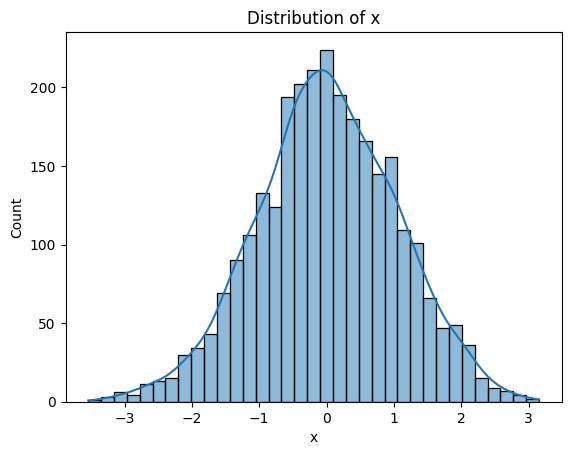

In [11]:
# overall distribution of x
print('mean x: ', data['x'].mean(), '|', 'std x: ', data['x'].std())

sns.histplot(data['x'], kde=True)
plt.title('Distribution of x')
plt.show()

#normally distributed around 0 with unit variance

mean x liked:  0.5533389566782739 | std x liked:  1.0465616543089398
mean x not-liked:  -0.3840831894789679 | std x not-liked:  0.833477763489058


Text(0.5, 1.0, 'Distribution of x not-liked')

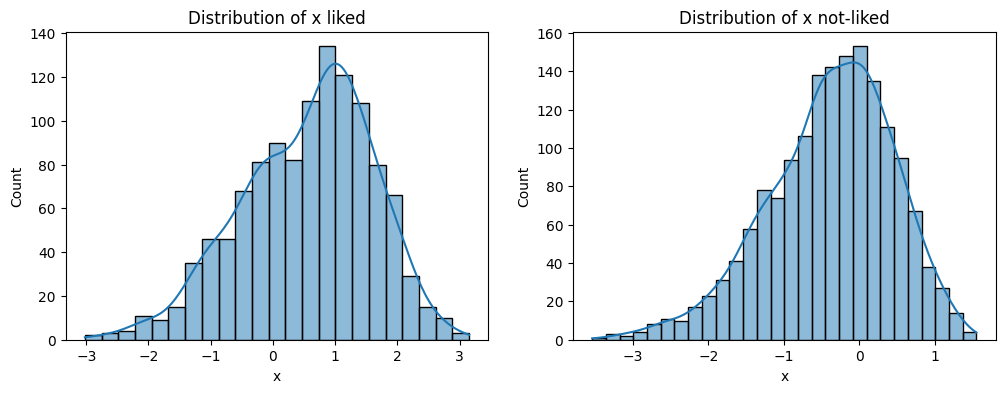

In [12]:
#distribution of x liked/not-liked
plt.close()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

print('mean x liked: ', data[data['liked']==1]['x'].mean(), '|', 'std x liked: ', data[data['liked']==1]['x'].std())
print('mean x not-liked: ', data[data['liked']==0]['x'].mean(), '|', 'std x not-liked: ', data[data['liked']==0]['x'].std())

sns.histplot(data[data['liked']==1]['x'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of x liked')
sns.histplot(data[data['liked']==0]['x'], kde=True, ax=ax[1])
ax[1].set_title('Distribution of x not-liked')


mean of x is higher in liked vs not liked

In [13]:
#quick stat tests to see if x's distribution is sig. diff. between liked/not-liked
ks_pval = ks_2samp(data[data['liked']==1]['x'], data[data['liked']==0]['x']).pvalue
ttest_pval = ttest_ind(data[data['liked']==1]['x'], data[data['liked']==0]['x']).pvalue
print('ks test pval: ', ks_pval)
print('t-test pval: ', ttest_pval)

ks test pval:  3.79393648145134e-117
t-test pval:  7.633707307129473e-137


Covariate x seems to carry some signal at least given that the distributions for liked and not-liked are sig. diff

------------------------------------
item:  1
number of likes (out of 100):  43
mean x liked:  0.680699415657861 | std x liked:  0.9799137420044749
mean x not-liked:  -0.376865866490953 | std x not-liked:  0.8346155907387004
------------------------------------
item:  2
number of likes (out of 100):  40
mean x liked:  0.6466839997774911 | std x liked:  0.9016876927316253
mean x not-liked:  -0.4627777612205874 | std x not-liked:  0.9177027051361012
------------------------------------
item:  3
number of likes (out of 100):  34
mean x liked:  0.34916932051325805 | std x liked:  1.1262511328799192
mean x not-liked:  -0.32446652121586667 | std x not-liked:  0.8379183620216045
------------------------------------
item:  4
number of likes (out of 100):  58
mean x liked:  0.6090285900750089 | std x liked:  0.8786565869517327
mean x not-liked:  -1.051364904121342 | std x not-liked:  0.8008499488575599
------------------------------------
item:  5
number of likes (out of 100):  66
mean x liked:

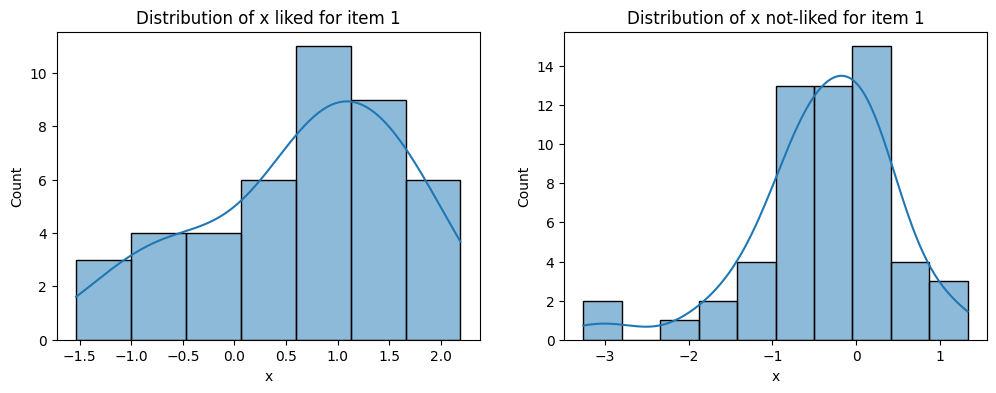

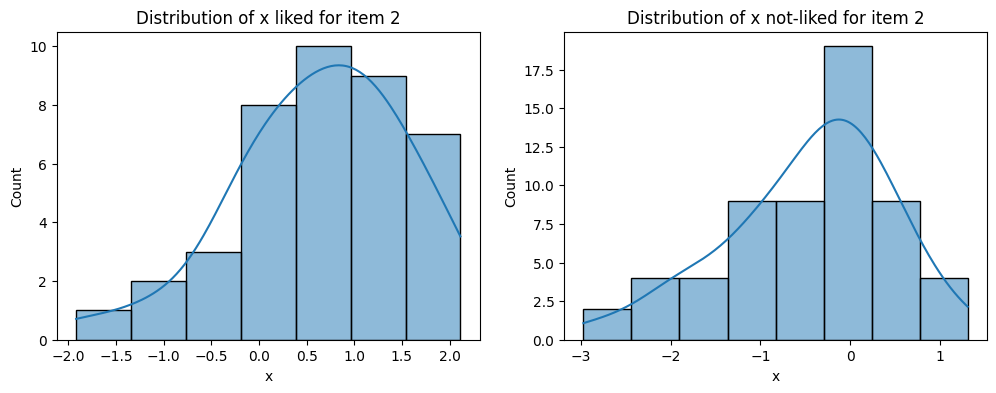

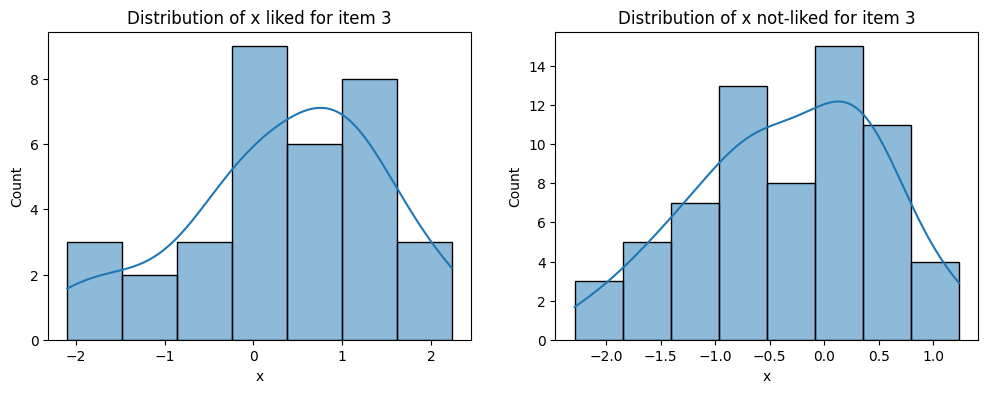

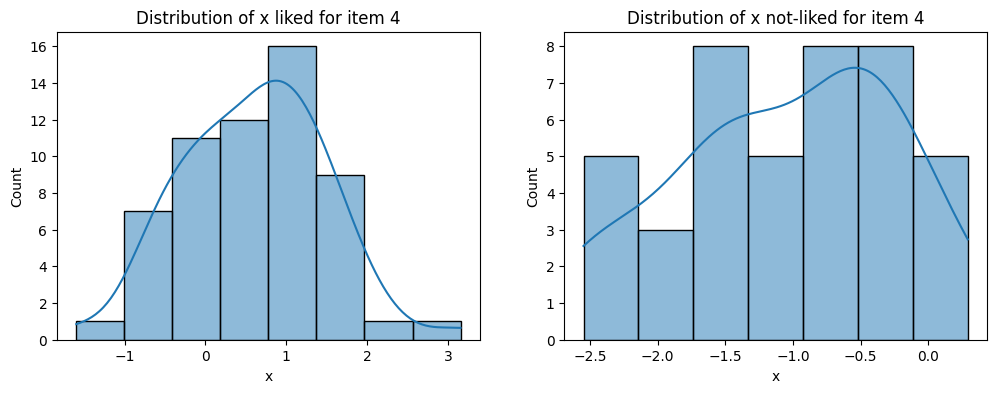

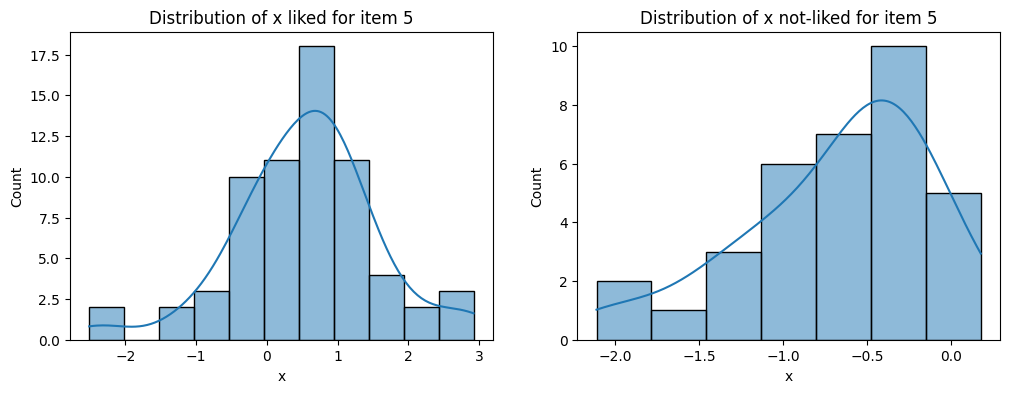

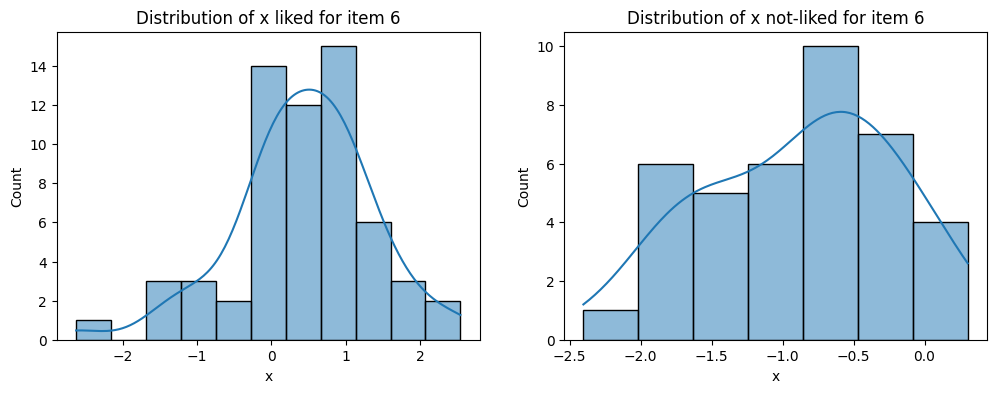

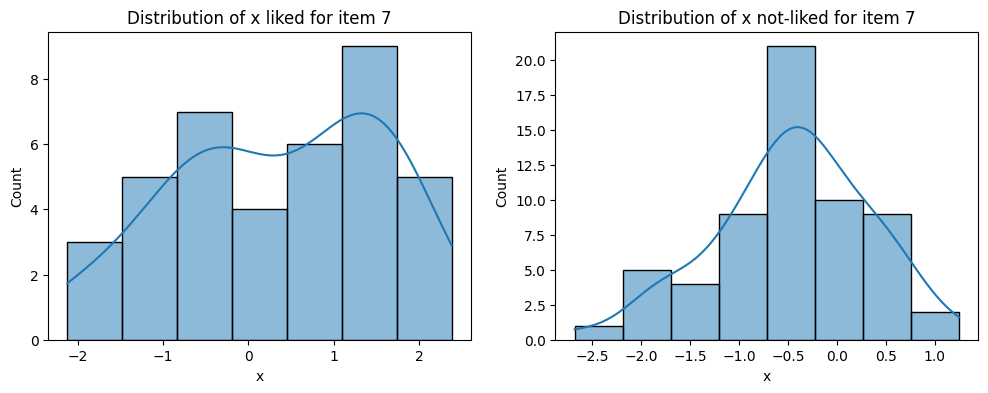

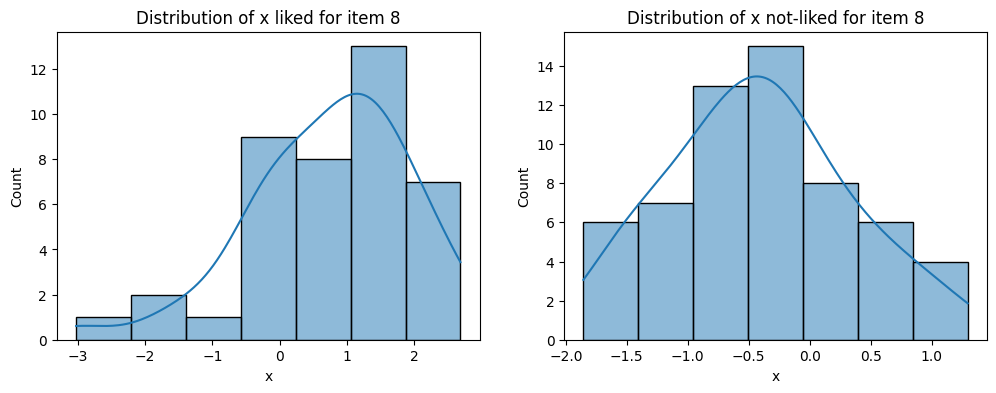

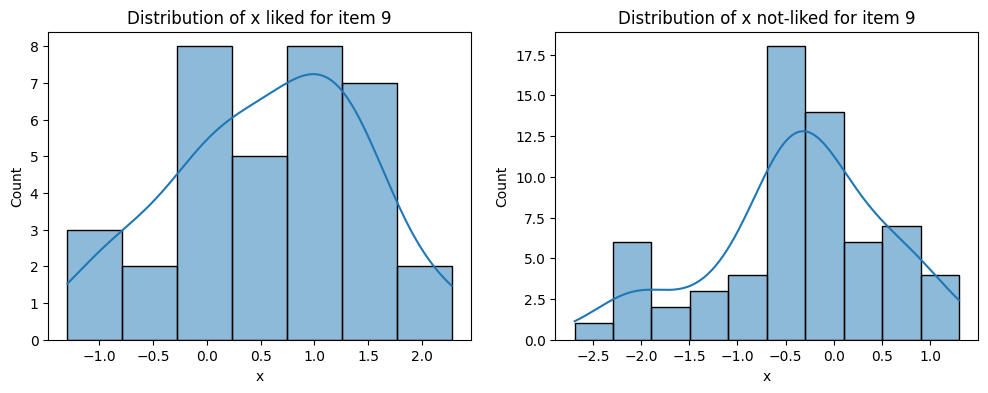

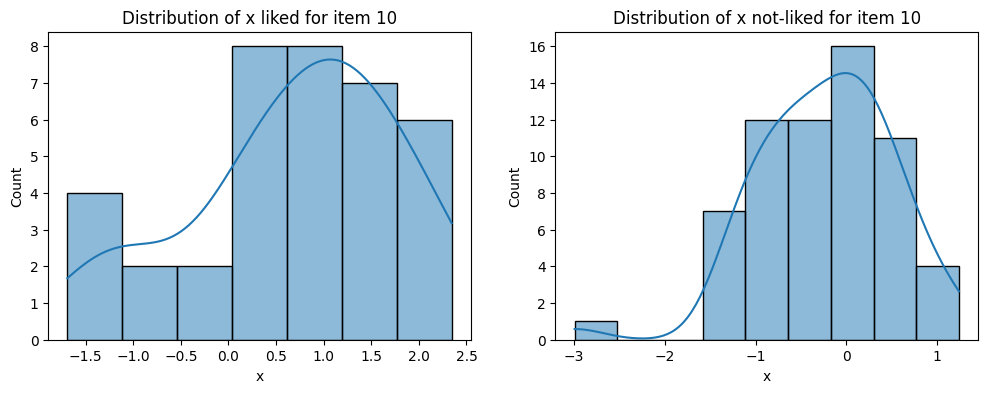

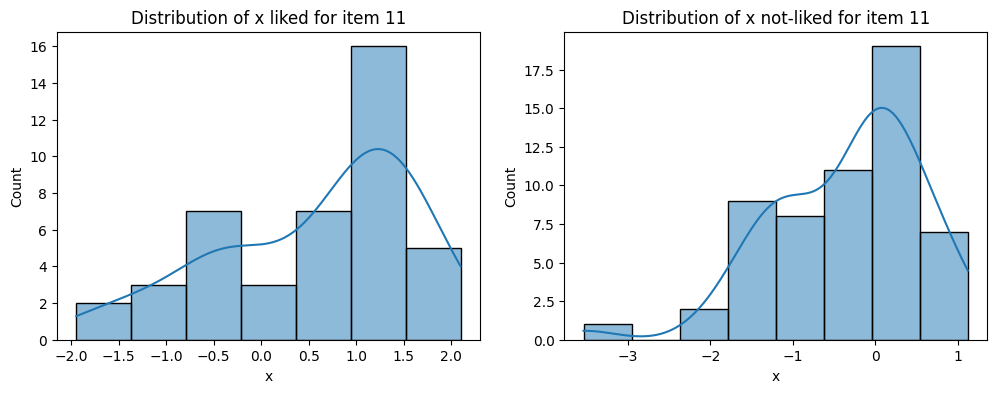

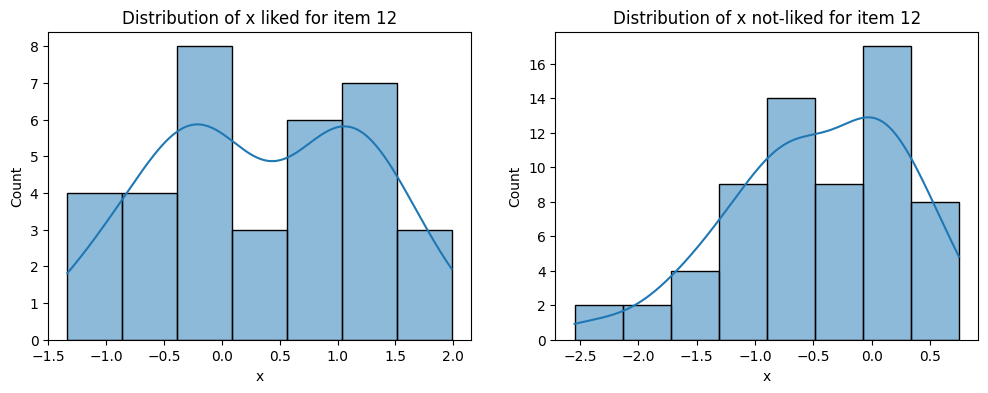

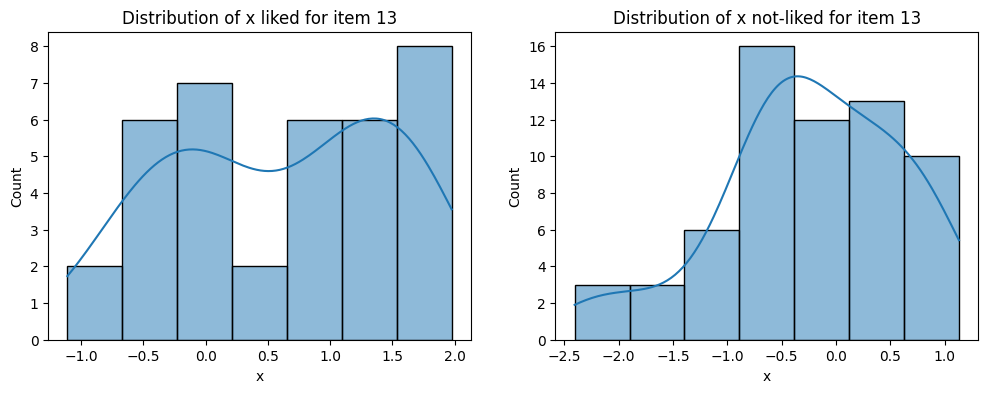

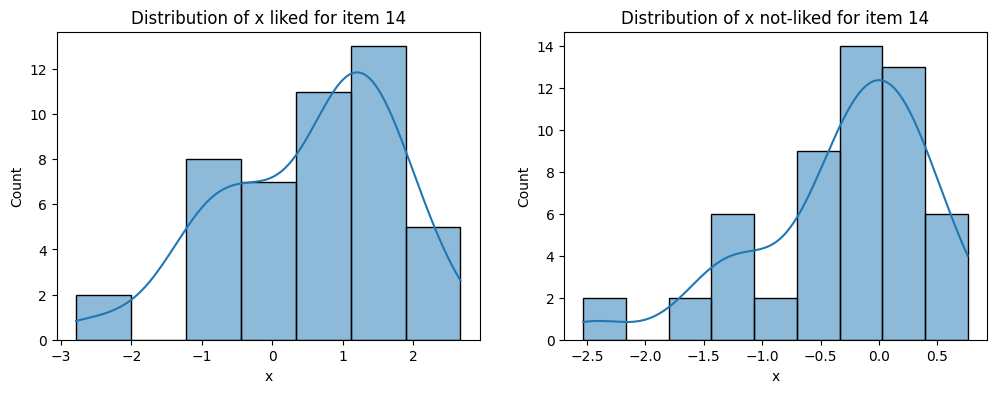

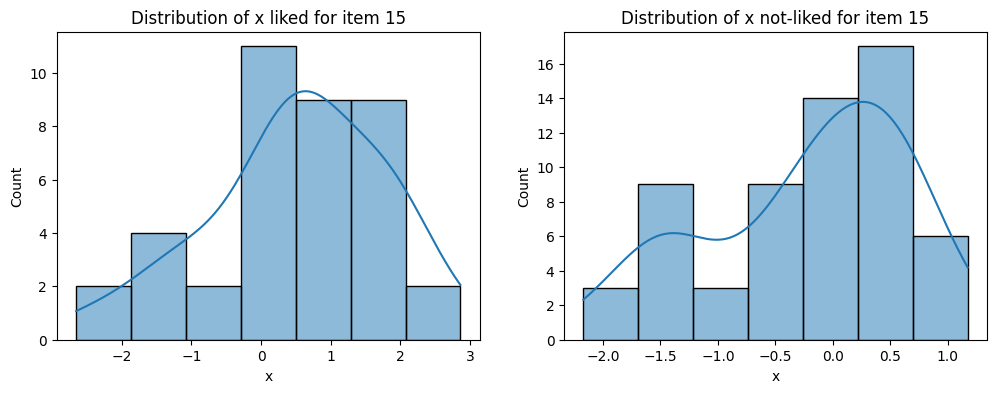

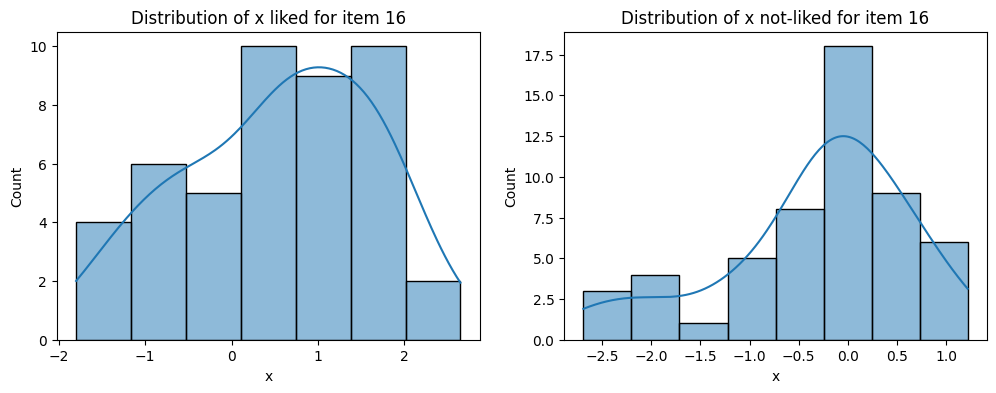

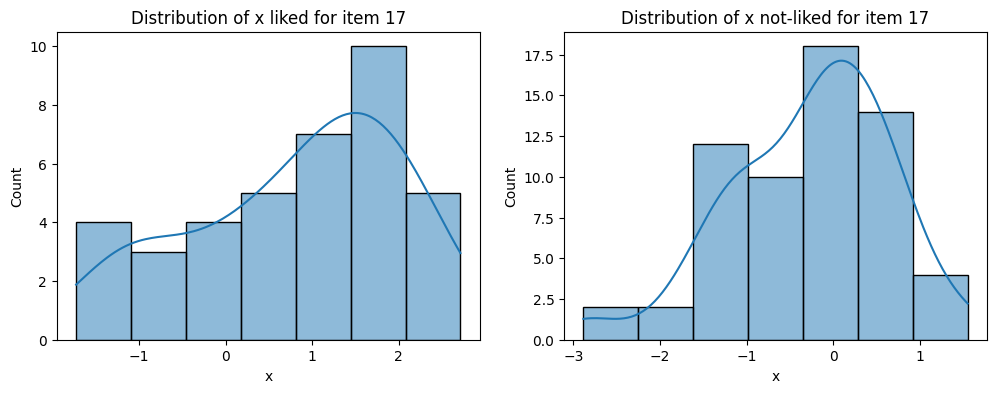

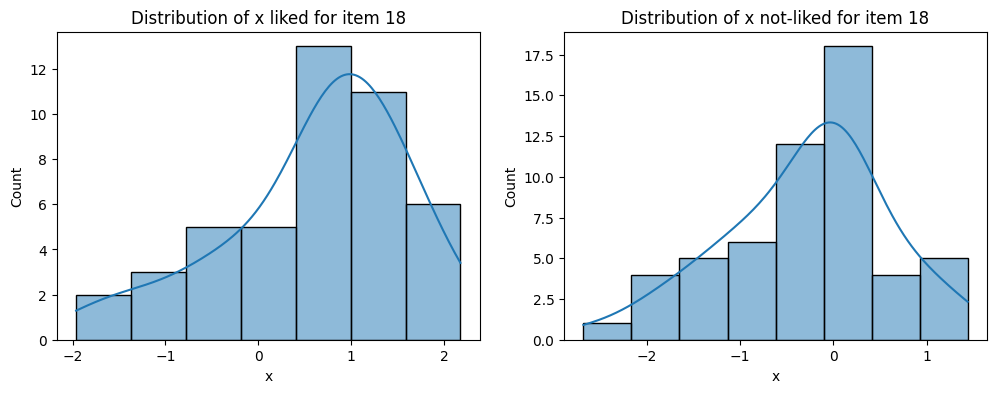

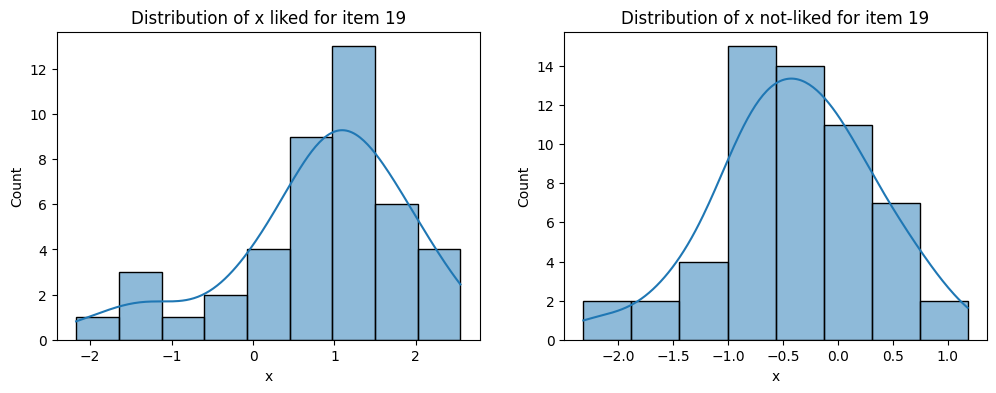

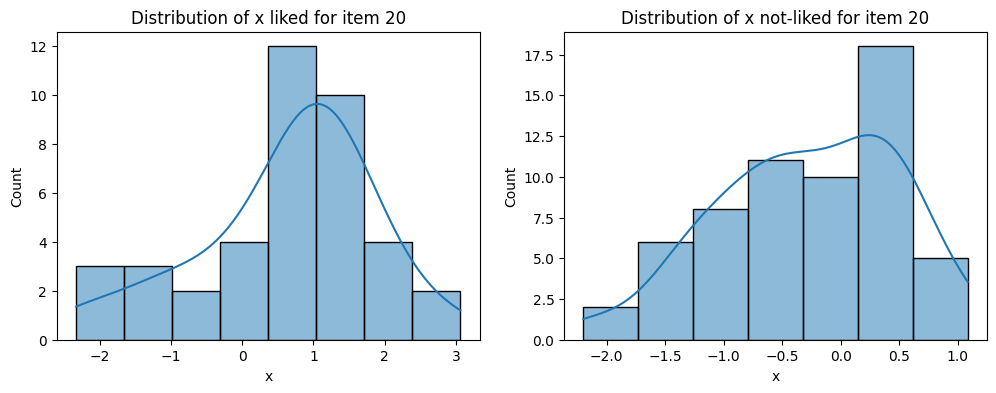

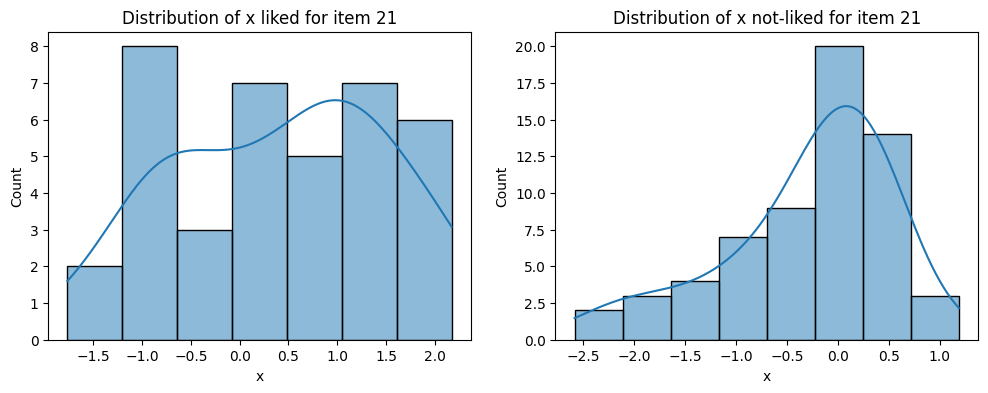

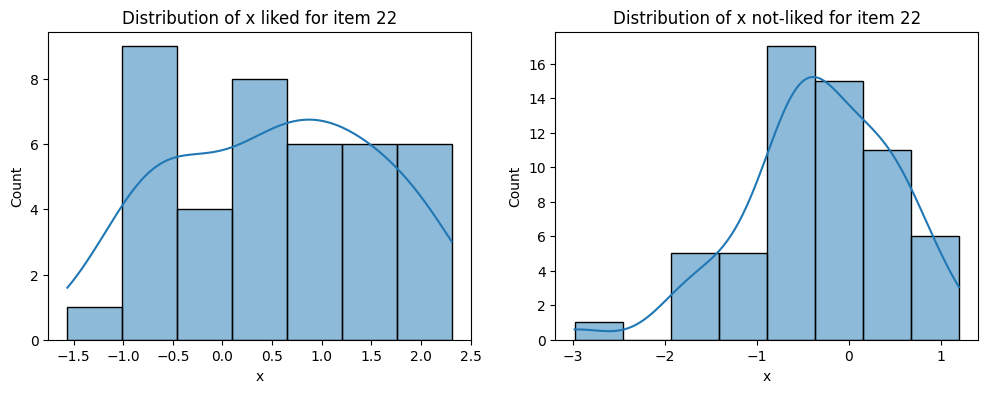

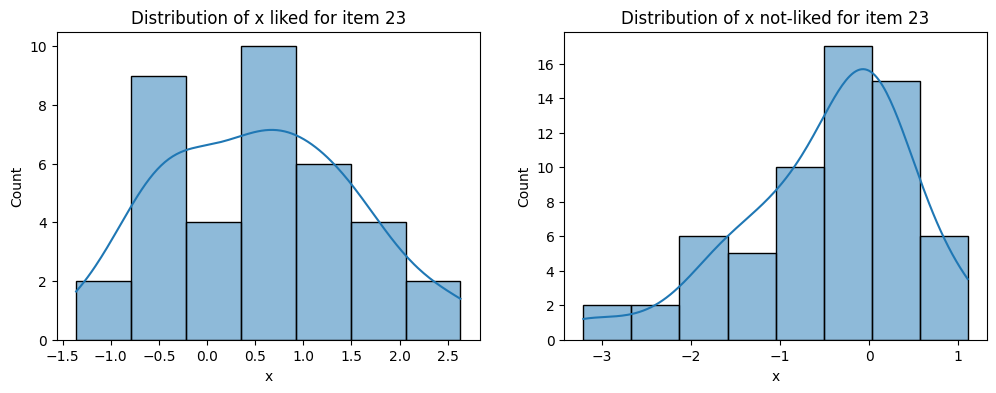

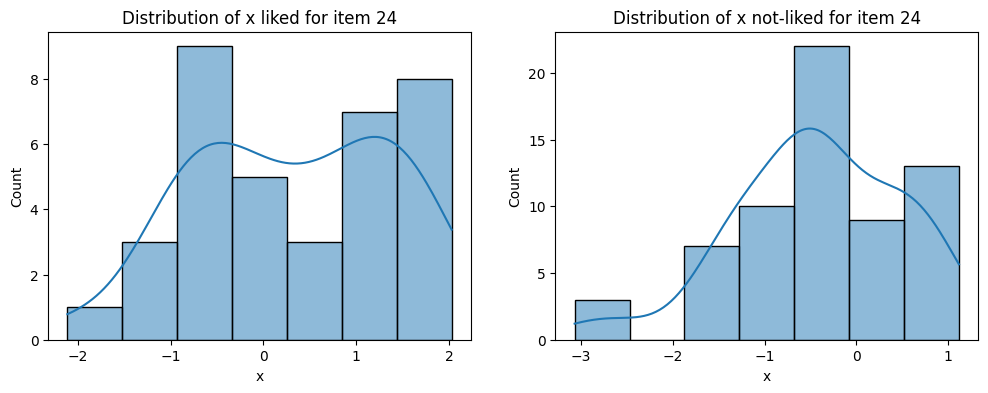

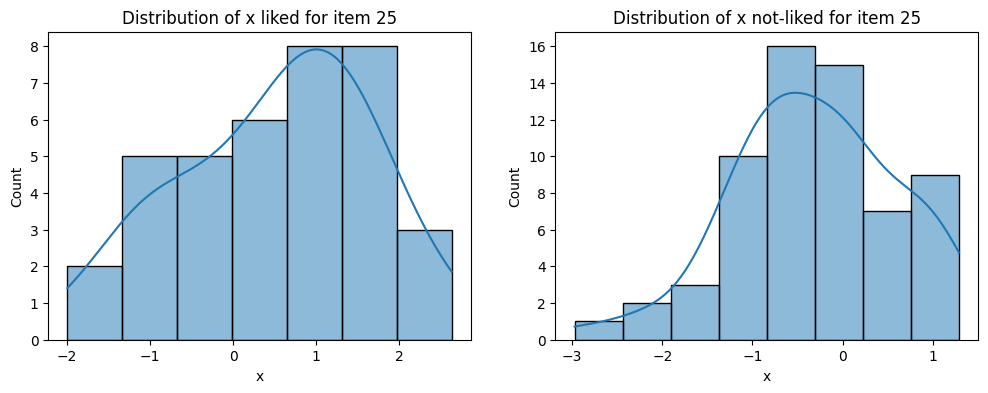

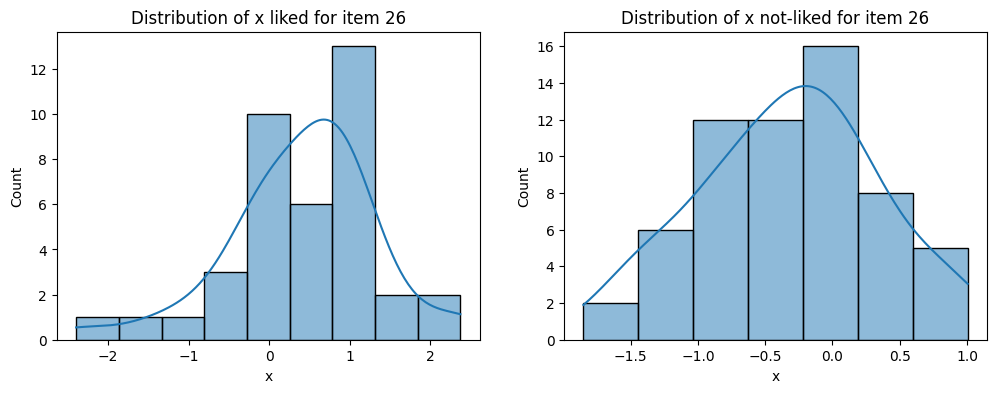

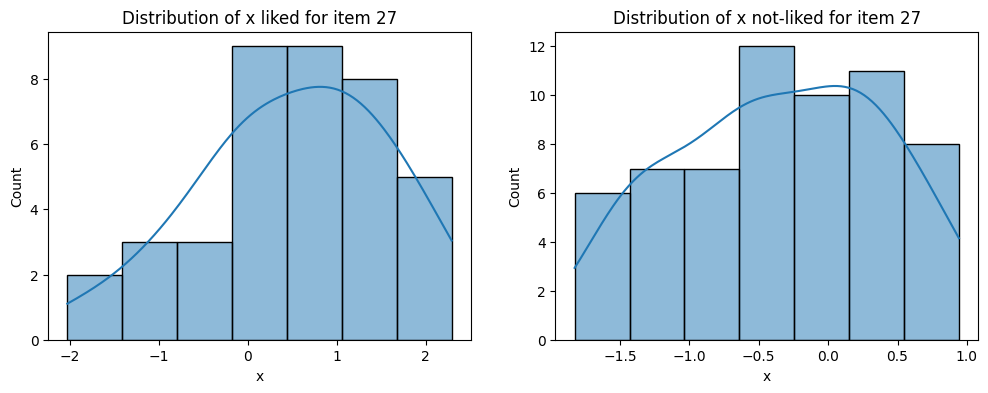

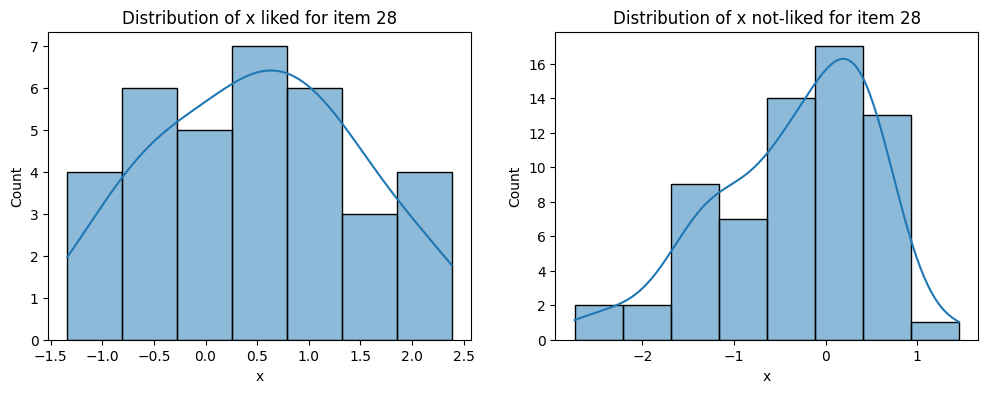

In [14]:
#distribution of x liked/not-liked across items/user - are there differences in the distribution of x (liked/not-liked) across different items?
#warning, cell produces A LOT of plots
for i in data.item.unique():
    print('------------------------------------')
    print('item: ', i)
    print('number of likes (out of 100): ', data[data['liked']==1][data['item']==i].shape[0])
    print('mean x liked: ', data[data['liked']==1][data['item']==i]['x'].mean(), '|', 'std x liked: ', data[data['liked']==1][data['item']==i]['x'].std())
    print('mean x not-liked: ', data[data['liked']==0][data['item']==i]['x'].mean(), '|', 'std x not-liked: ', data[data['liked']==0][data['item']==i]['x'].std())

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(data[data['liked']==1][data['item']==i]['x'], kde=True, ax=ax[0])
    ax[0].set_title(f'Distribution of x liked for item {i}')
    sns.histplot(data[data['liked']==0][data['item']==i]['x'], kde=True, ax=ax[1])
    ax[1].set_title(f'Distribution of x not-liked for item {i}')

Some items appear to have different distributions of x, let's spot check with ttest/ks test

In [15]:
#item 17 and 12 appear to have a large difference in distribution of x (liked) - let's test this
stat, pval = ttest_ind(data[data['liked']==1][data['item']==17]['x'], data[data['liked']==1][data['item']==12]['x'])
print('t-test pval: ',  pval)
stat, pval = ks_2samp(data[data['liked']==1][data['item']==17]['x'], data[data['liked']==1][data['item']==12]['x'])
print('KS test pval: ',  pval)

t-test pval:  0.06594674127703912
KS test pval:  0.04535185506215115


P values aren't very low, I will assume apparent distributional differences in x across items are just due to chance. I am not surprised given the perfectly normal overall distribution of x. In practice if we had reason to believe covariate x was very important to the task, we could spend more time seperating out different distributions of x for more information, like engineering cluster features. But for now, given the weak evidence of distributional difference, let's assume there isn't any variation in the distribution of x across items. I will also assume there aren't any significant distributional differences in x across users.

Text(0.5, 1.0, 'Distribution of x not-liked for outlier items')

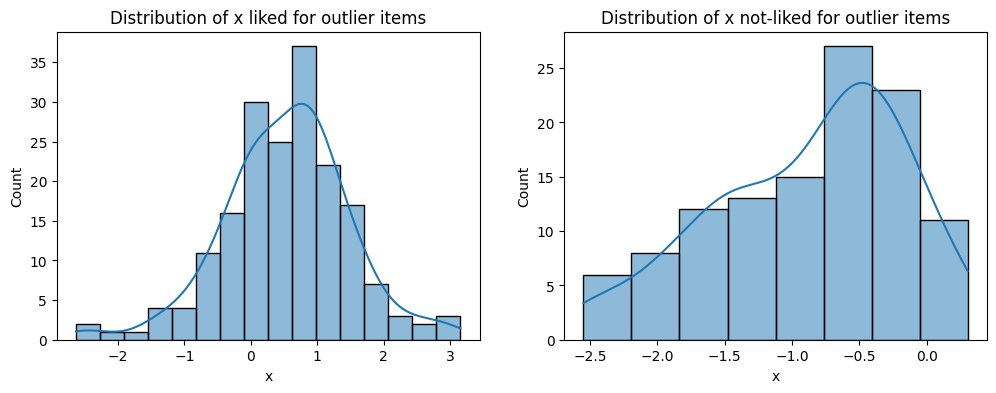

In [16]:
#how does x present in outlier items and users?

#distribution of x liked/disliked for outlier items
plt.close()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data[data['liked']==1][data['item'].isin(outlier_items.index)]['x'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of x liked for outlier items')
sns.histplot(data[data['liked']==0][data['item'].isin(outlier_items.index)]['x'], kde=True, ax=ax[1])
ax[1].set_title('Distribution of x not-liked for outlier items')

For outlier items, the liked/not-liked distribution is similar to the overall distributions

Text(0.5, 1.0, 'Distribution of x not-liked for outlier users')

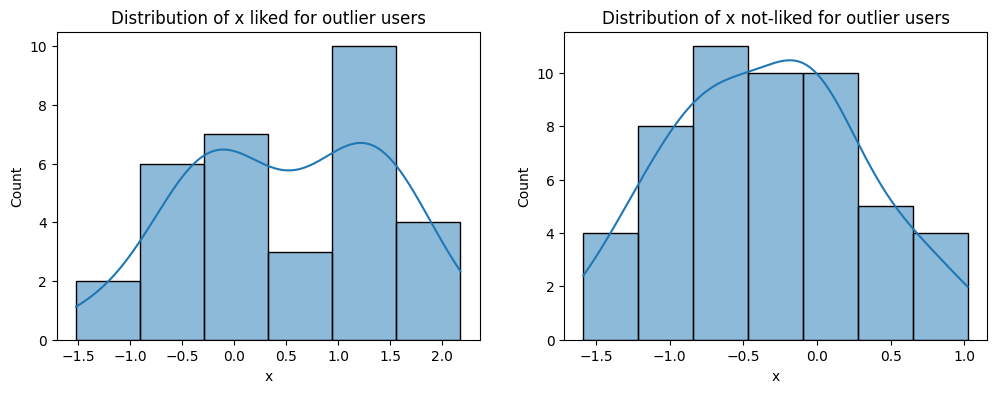

In [17]:
#distribution of x liked/disliked for outlier users
plt.close()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data[data['liked']==1][data['user'].isin(outlier_users.index)]['x'], kde=True, ax=ax[0])
ax[0].set_title('Distribution of x liked for outlier users')
sns.histplot(data[data['liked']==0][data['user'].isin(outlier_users.index)]['x'], kde=True, ax=ax[1])
ax[1].set_title('Distribution of x not-liked for outlier users')

same case for outlier users.

## Modeling

### Stage 1: User-item interactions

Without any additional covariates besides x, the only other pieces of information available to learn the pattern of an item being liked vs. not liked is through the binary user-item interactions. We have a total of 100 unique users and 28 unique items, resulting in 2800 interactions. To represent these interactions in a meaningful way (i.e. to identify latent user/item preferences/factors), we can use matrix decomposition to capture the most informative (i.e. highest variance) components of the user-item interactions so we can generalize onto unknown elements in the user-item matrix and make predictions. For this reason I chose to use Singular Value Decomposition/Matrix Factorization as my approach.

In [18]:
#some functions for modeling

#conversion functions of recommendation scores to probabilities
#sigmoid function
def sigmoid(x):
    return 1/(1 + np.exp(-x))

#min_max scaling function
def min_max_prob(x):
    min_val = x.min() 
    max_val = x.max()
    return (x - min_val) / (max_val - min_val)

#calculating PR-AUC
def prauc(y_true, y_pred):
    prauc = auc(*precision_recall_curve(y_true, y_pred)[:2][::-1])
    return prauc 


In [19]:
#use LightFM's implementation for MF because it includes native support for addtitional covariate information like x 
from lightfm import LightFM
from scipy.sparse import coo_matrix, csr_matrix

In [20]:
#split training into train/valid and check that all users and items are present in train
df_train, df_valid = train_test_split(df_train, test_size=0.2, random_state=seed)
df_train.user.nunique(), df_train.item.nunique()

(100, 28)

In [21]:
#create the interaction matrix R = [users, items]
pivot = df_train.pivot(index='user', columns='item', values='liked').fillna(0)

#replace 0 values in matrix with -1 for greater seperation between liked and not-liked
pivot = pivot.replace(0, -1)

#LightFM requires a scipy coo_matrix as input, so convert R
R = pivot.to_numpy()
R = coo_matrix(R)
# print(R)

#instantiate a LightFM model - we'll start with k = 5 (toal rank of matrix is 28) and 5 epochs
model = LightFM(no_components=5, random_state=seed)
model.fit(R, epochs=5)

In [22]:
#evaluate performance on valid set
print('Proportion of liked items in valid set: ', df_valid.liked.mean())

#prepare test input into format for LightFM model predictions. Since the input coo_matrices start with an index 0, we have to subtract 1 from user and item numbers (0-27 instead of 1-28)
valid_user_idx = df_valid['user'].values - 1
valid_item_idx = df_valid['item'].values - 1

#score using sigmoid transformation
s_preds = sigmoid(model.predict(user_ids=valid_user_idx, item_ids=valid_item_idx))
print('Validation AUC: ', roc_auc_score(df_valid['liked'].values, s_preds))
print('Validation PR-AUC: ', prauc(df_valid['liked'].values, s_preds))

Proportion of liked items in valid set:  0.38966202783300197
Validation AUC:  0.4520541115468989
Validation PR-AUC:  0.372830415505384


Performance of initial model on in-sample data is poor. Use a small grid search space to see if any performance gains can be obtained. I suspect k (number of dimensions in the lower-rank approximation) needs to be higher and perhaps more training loops need to occur.

Best AUC:  0.7655221697799642 | Best params: {'no_components': 13, 'epochs': 19}
CPU times: total: 7.89 s
Wall time: 7.89 s


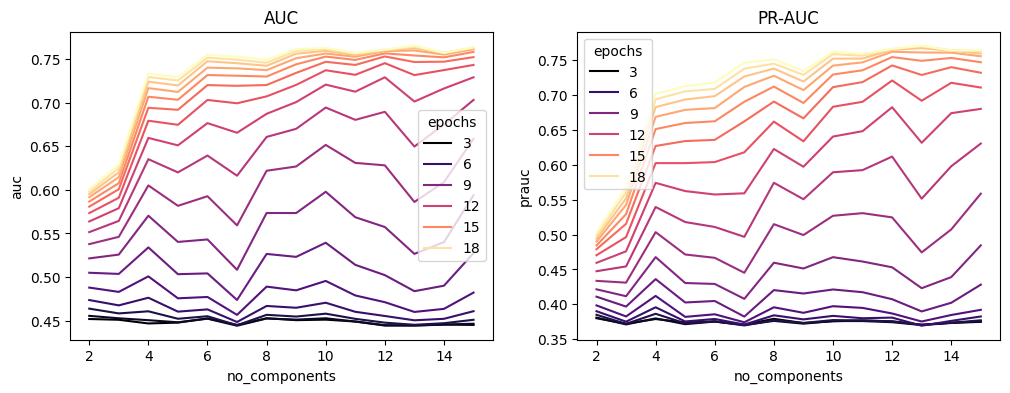

In [23]:
%%time
#define search space
grid = {
    'no_components': np.arange(2, 16),
    'epochs': np.arange(3, 20)
}

#initialize results storage objects
rst = {
    'no_components': [],
    'epochs': [],
    'auc': [],
    'prauc': []
}

best_params = {
    'no_components': 0,
    'epochs': 0,
}

best_auc = 0

#grid search with sigmoid transform and save the best parameters (objective: AUC)
for n in grid['no_components']:
    for e in grid['epochs']:
        model = LightFM(no_components=n, random_state=seed)
        model.fit(R, epochs=e)
        s_preds = sigmoid(model.predict(user_ids=valid_user_idx, item_ids=valid_item_idx))
        auc_score = roc_auc_score(df_valid['liked'].values, s_preds)
        prauc_score = prauc(df_valid['liked'].values, s_preds)
        # print('------------------------------------')
        # print(f'eval metrics for k={n}, epochs={e}')
        # print('AUC: ', auc_score, '| PR-AUC: ', prauc_score)

        if auc_score > best_auc:
            best_auc = auc_score
            best_params['no_components'] = n
            best_params['epochs'] = e

        rst['no_components'].append(n)
        rst['epochs'].append(e)
        rst['auc'].append(auc_score)
        rst['prauc'].append(prauc_score)

rst_df = pd.DataFrame(rst)

#plot performance curves
plt.close()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=rst_df, x='no_components', y='auc', hue='epochs', palette='magma', ax=ax[0])
ax[0].set_title('AUC')
sns.lineplot(data=rst_df, x='no_components', y='prauc', hue='epochs',  palette='magma', ax=ax[1])
ax[1].set_title('PR-AUC')

print('Best AUC: ', best_auc, '| Best params:', best_params)

Performance on out of sample set peaks at 13 components and 19 epochs. Rebuild final model with these hyperparameters

Validation AUC:  0.7655221697799642
Validation PR-AUC:  0.7706022169963616
mean:  -0.7423388
std:  1.3204998
min:  -3.7536232
max:  3.1009257


<Axes: ylabel='Count'>

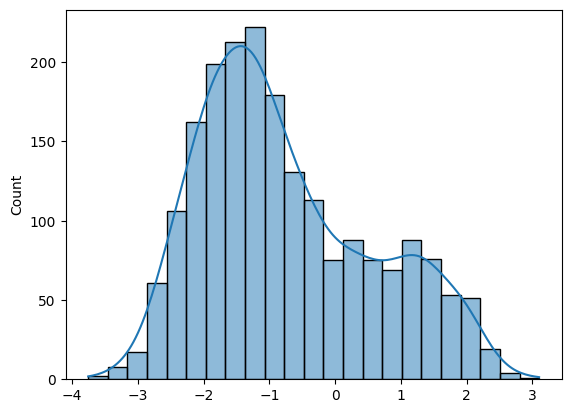

In [24]:
#valid the final model and obtain estimates of interaction strength to use as a feature in stage 2 logistic regression
model = LightFM(no_components=best_params['no_components'], random_state=seed)
model.fit(R, epochs=best_params['epochs'])

#performance on valid
#get user and item indicies
valid_user_idx = df_valid['user'].values - 1
valid_item_idx = df_valid['item'].values - 1

#evaluate
s_preds = sigmoid(model.predict(user_ids=valid_user_idx, item_ids=valid_item_idx))
print('Validation AUC: ', roc_auc_score(df_valid['liked'].values, s_preds))
print('Validation PR-AUC: ', prauc(df_valid['liked'].values, s_preds))

#generate recommendation scores for stage 2 modeling
train_user_idx = df_train['user'].values - 1
train_item_idx = df_train['item'].values - 1

train_rec_score = model.predict(user_ids=train_user_idx, item_ids=train_item_idx)
valid_rec_score = model.predict(user_ids=valid_user_idx, item_ids=valid_item_idx)

#some stats/distribution on rec_score, for potential feature normalization in the next stage model
print('mean: ', train_rec_score.mean())
print('std: ', train_rec_score.std())
print('min: ', train_rec_score.min())
print('max: ', train_rec_score.max())

plt.close()
sns.histplot(train_rec_score, kde=True)

Given that x is normalized with mean 0 and SD 1, I will normalize rec_score the same way

## Stage 2: Logistic Regression Incorporating Covariate x

Why Logistic Regression? Given the small dataset, I would like to avoid overfitting risks with using a more complex model (i.e. tree-based). Additionally, there is reasonable evidence that the relationship between x and liked is linear, given the clean seperation of the two distributions for liked = 1 and liked = 0 in x.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler 

#prepare data for training - fit a standardscaler to normalize rec_score
standardizer = StandardScaler().fit(X=train_rec_score.reshape(-1, 1))
df_train['rec_score'] = standardizer.transform(train_rec_score.reshape(-1, 1))


#fit LR
lr_model = LogisticRegression(random_state=seed)
lr_model.fit(df_train[['rec_score', 'x']], df_train['liked'])

#evaluate LR model's performance on valid
df_valid['rec_score'] = standardizer.transform(valid_rec_score.reshape(-1, 1))
lr_preds = lr_model.predict_proba(df_valid[['rec_score', 'x']])[:, 1]
print('Validation AUC: ', roc_auc_score(df_valid['liked'], lr_preds))
print('Validation PR-AUC: ', prauc(df_valid['liked'], lr_preds))



Validation AUC:  0.8676294622083361
Validation PR-AUC:  0.8254512269390255


Compared to predictions made just with the matrix factorization model, the stage 2 model incorporating covariate x performs about 10% better (AUC) on the validation set.

### Evaluation on Test

In [26]:
#evaluate just the MF model on test

#prepare test input into format for LightFM model predictions
test_user_idx = df_test['user'].values - 1
test_item_idx = df_test['item'].values - 1

#score using sigmoid transformation
s_preds = sigmoid(model.predict(user_ids=test_user_idx, item_ids=test_item_idx))
print('Test AUC: ', roc_auc_score(df_test['liked'].values, s_preds))
print('Test PR-AUC: ', prauc(df_test['liked'].values, s_preds))

#generate recommendation scores
test_rec_score = model.predict(user_ids=test_user_idx, item_ids=test_item_idx)
df_test['rec_score'] = standardizer.transform(test_rec_score.reshape(-1, 1))

Test AUC:  0.8150505050505051
Test PR-AUC:  0.8196040918200781


In [27]:
#evalute on stage 2 LR model
lr_preds = lr_model.predict_proba(df_test[['rec_score', 'x']])[:, 1]
print('Test AUC: ', roc_auc_score(df_test['liked'], lr_preds))
print('Test PR-AUC: ', prauc(df_test['liked'], lr_preds))

Test AUC:  0.8973232323232323
Test PR-AUC:  0.8857097227400935


In [28]:
#Explanability - LR
print('LR Coefficients: ', lr_model.feature_names_in_[0], ' = ', lr_model.coef_[0][0], '|', lr_model.feature_names_in_[1], ' = ', lr_model.coef_[0][1])
print('LR Intercept: ', lr_model.intercept_)


LR Coefficients:  rec_score  =  5.481201032003875 | x  =  2.674767433386747
LR Intercept:  [-0.9853442]


In [34]:
#Interpret the intercept as base odds of liking an item after applying an exponentiation to it (its a logit)
base_odds = np.exp(lr_model.intercept_)[0]
base_prob = base_odds / (1 + base_odds)
base_prob

0.2718326658729192

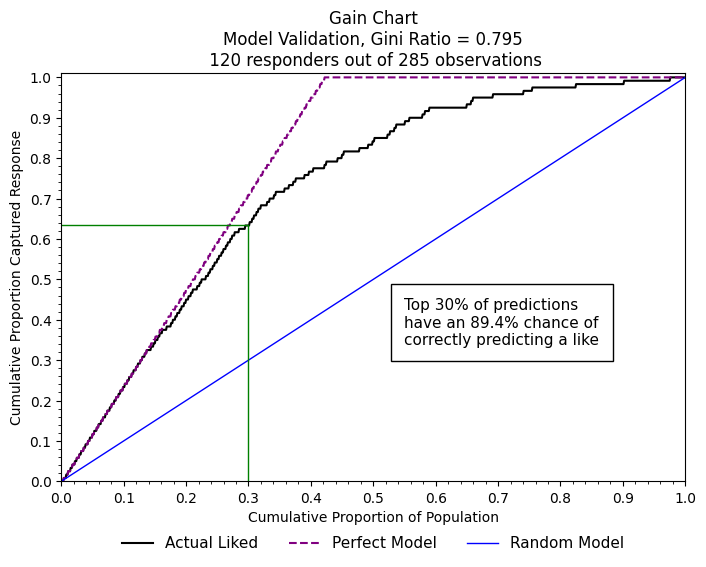

Accuracy of top 20% of predictions:  0.9473684210526315
Accuracy of top 15% of predictions:  0.9761904761904762


In [43]:
#Performance plot - gain chart to show performance of model on top X percentile of predictions
from matplotlib.ticker import AutoMinorLocator

#Gain on test set
Data = []
List = list(df_test['liked'])
ListP = list(lr_preds)
for i in range(len(List)):
    Data.append([List[i], ListP[i]])
Data.sort(key = lambda x: x[1]*-1)
Data2 = copy.deepcopy(Data)
Data2.sort(key = lambda x: x[0]*-1)
n0 = len(list(filter(lambda x: x[0] == 0, Data)))
n1 = len(list(filter(lambda x: x[0] == 1, Data)))
pointsX = []
pointsY = []
gini = 2.*roc_auc_score(df_test['liked'], ListP) - 1.
optimal = []
Npoints = 1000
for i in range(Npoints+1):
    if i <=1:
        start, end = 0, int(i/(1.*Npoints)*len(Data))
    else:
        start = int((i-1)/(1.*Npoints)*len(Data))
        end = int(i/(1.*Npoints)*len(Data))
    tmp = Data[start:end]
    pointsX.append(i/(1.*Npoints))
    pointsY.append(len(list(filter(lambda x:x[0]==1,tmp))))
    tmp = Data2[start:end]
    optimal.append(sum(list(map(lambda x:x[0], tmp))))
pointsY = np.cumsum(pointsY)/n1
optimal = np.cumsum(optimal)/np.sum(optimal)
top30pred = [x[0] for x in Data[:int(.3*len(Data))]]
AccAt30 = top30pred.count(1)/len(top30pred)
PointAt30 = pointsY[int(.3*Npoints)]

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(pointsX, pointsY, '-',color='black',label="Actual Liked")
plt.plot(pointsX,optimal,color='purple',linewidth=1.5,linestyle='--',label="Perfect Model")
plt.plot((min(pointsX),max(pointsX)),(min(pointsX),max(pointsX)),color='blue',linewidth=1,linestyle='-',label="Random Model")
plt.plot((0.3,0.3),(0,PointAt30),color='green',linewidth=1,linestyle='-')
plt.plot((0.,0.3),(PointAt30,PointAt30),color='green',linewidth=1,linestyle='-')
plt.xlabel("Cumulative Proportion of Population")
plt.ylabel("Cumulative Proportion Captured Response")
plt.title("Gain Chart\nModel Validation, Gini Ratio = "+str(round(gini,3))+"\n "+str(n1)+" responders out of "+str(n0+n1)+" observations")
plt.subplots_adjust(left=0.12, right=0.9, top=0.86, bottom=0.18)
plt.yticks(np.arange(0, 1.01, .1))
plt.xticks(np.arange(0, 1.01, .1))
plt.xlim(0.,1.)
plt.ylim(0.,1.01)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='upper center',frameon=False,bbox_to_anchor=(0.5, -0.10),fancybox=False, shadow=False, ncol=5,fontsize=11)
ax.text(0.55, 0.45, "Top 30% of predictions\nhave an "+str(round(AccAt30*100., 1))+'% chance of\ncorrectly predicting a like', transform=ax.transAxes, fontsize=11,
verticalalignment='top', bbox=dict(facecolor='none', edgecolor='black', pad=10.0))

plt.show()

print('Accuracy of top 20% of predictions: ', [x[0] for x in Data[:int(.2*len(Data))]].count(1)/len([x[0] for x in Data[:int(.2*len(Data))]]))
print('Accuracy of top 15% of predictions: ', [x[0] for x in Data[:int(.15*len(Data))]].count(1)/len([x[0] for x in Data[:int(.15*len(Data))]]))

Targetting the top 30% of predictions has an 89% chance of being correct (liked). Can get even more accurate with the top 20 or 15% of predictions. Something to consider if accuracy of recommendation is very important (i.e. monetary offer campaign, etc).

### Submission

In [37]:
#output required predictions to csv
df_test['y_pred'] = lr_preds
submission = df_test[df_test['user']<6][['user', 'item', 'y_pred', 'liked']].sort_values(by=['user', 'item'], ascending=True)
submission.to_csv('tl_submission.csv', index=False)
submission.head()

,user,item,y_pred,liked
700,1,8,0.000120,0
601,2,7,0.000441,0
701,2,8,0.000380,0
2001,2,21,0.000779,0
2201,2,23,0.025686,0


In [35]:
#sanity checks on df_test
df_test_check = data[data['observed'] == 0]
print('total test instances', df_test.shape[0])
print('total test (check) instances', df_test_check.shape[0])

print('total test instances for users 1 to 5: ', df_test[df_test['user']<6].shape[0])
print('total test (check) instances for users 1 to 5: ', df_test_check[df_test_check['user']<6].shape[0])
print('total submission instances: ', submission.shape[0])

total test instances 285
total test (check) instances 285
total test instances for users 1 to 5:  21
total test (check) instances for users 1 to 5:  21
total submission instances:  21


Accuracy of top 20% of predictions:  0.0
